# Maternal Mortality Trends: New Jersey vs United States

This project analyzes CDC WONDER mortality data to examine trends and racial disparities
in maternal mortality, comparing New Jersey with national patterns.

In [5]:
import pandas as pd

# Load CDC WONDER exports
us = pd.read_csv("/Users/kellykroeper/maternal_mortality/maternal_mortality_us.csv")
nj = pd.read_csv("/Users/kellykroeper/maternal_mortality/maternal_mortality_nj.csv")

# Peek at structure
us.head(), nj.head()

(  Notes    Year  Year Code                              Single Race 6  \
 0   NaN  2018.0     2018.0           American Indian or Alaska Native   
 1   NaN  2018.0     2018.0                                      Asian   
 2   NaN  2018.0     2018.0                  Black or African American   
 3   NaN  2018.0     2018.0  Native Hawaiian or Other Pacific Islander   
 4   NaN  2018.0     2018.0                                      White   
 
   Single Race 6 Code     Deaths   Population  Crude Rate  \
 0             1002-5     8549.0    2058223.0       415.4   
 1                  A    34105.0   10111594.0       337.3   
 2             2054-5   165588.0   22818244.0       725.7   
 3              NHOPI     1597.0     394257.0       405.1   
 4             2106-3  1164448.0  126137500.0       923.2   
 
    Crude Rate Lower 95% Confidence Interval  \
 0                                     406.6   
 1                                     333.7   
 2                                     722

In [6]:
df = pd.concat([us, nj], ignore_index=True)

df.head()

,Notes,Year,Year Code,Single Race 6,Single Race 6 Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval
0,NaN,2018.0,2018.0,American Indian or Alaska Native,1002-5,8549.0,2058223.0,415.4,406.6,424.2
1,NaN,2018.0,2018.0,Asian,A,34105.0,10111594.0,337.3,333.7,340.9
2,NaN,2018.0,2018.0,Black or African American,2054-5,165588.0,22818244.0,725.7,722.2,729.2
3,NaN,2018.0,2018.0,Native Hawaiian or Other Pacific Islander,NHOPI,1597.0,394257.0,405.1,385.2,424.9
4,NaN,2018.0,2018.0,White,2106-3,1164448.0,126137500.0,923.2,921.5,924.8


In [34]:
# Drop rows with missing or suppressed rates
df = df[df["rate"].notna()]

# Ensure year is numeric
df["year"] = df["year"].astype(int)

# Sort for sanity
df = df.sort_values(["location", "race", "year"])

df.info()

<class 'pandas.DataFrame'>
Index: 87 entries, 113 to 48
Data columns (total 11 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Notes                                     7 non-null      str    
 1   year                                      87 non-null     int64  
 2   Year Code                                 87 non-null     float64
 3   race                                      80 non-null     str    
 4   Single Race 6 Code                        80 non-null     str    
 5   deaths                                    87 non-null     float64
 6   population                                87 non-null     float64
 7   rate                                      87 non-null     float64
 8   Crude Rate Lower 95% Confidence Interval  87 non-null     float64
 9   Crude Rate Upper 95% Confidence Interval  87 non-null     float64
 10  location                                  87 non-null 

In [8]:
list(df.columns)

['Notes',
 'Year',
 'Year Code',
 'Single Race 6',
 'Single Race 6 Code',
 'Deaths',
 'Population',
 'Crude Rate',
 'Crude Rate Lower 95% Confidence Interval',
 'Crude Rate Upper 95% Confidence Interval']

In [9]:
# Find the rate column (handles variations in CDC WONDER headers)
rate_candidates = [c for c in df.columns if "Rate" in c or "rate" in c]
rate_candidates

['Crude Rate',
 'Crude Rate Lower 95% Confidence Interval',
 'Crude Rate Upper 95% Confidence Interval']

In [10]:
# Pick the best candidate: prefer Crude Rate if present, otherwise use the first Rate-like column
rate_col = None
for c in df.columns:
    if "Crude Rate" in c:
        rate_col = c
        break
if rate_col is None and len(rate_candidates) > 0:
    rate_col = rate_candidates[0]

print("Using rate column:", rate_col)

# Rename it to 'rate'
df = df.rename(columns={rate_col: "rate"})

Using rate column: Crude Rate


In [11]:
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")
df = df[df["rate"].notna()]

In [35]:
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df = df[df["year"].notna()].copy()
df["year"] = df["year"].astype(int)

df = df.sort_values(["location", "race", "year"])
df.head()

,Notes,year,Year Code,race,Single Race 6 Code,deaths,population,rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval,location
113,NaN,2018,2018.0,American Indian or Alaska Native,1002-5,30.0,26569.0,112.9,76.2,161.2,New Jersey
119,NaN,2019,2019.0,American Indian or Alaska Native,1002-5,25.0,26864.0,93.1,60.2,137.4,New Jersey
124,NaN,2020,2020.0,American Indian or Alaska Native,1002-5,40.0,29240.0,136.8,97.7,186.3,New Jersey
130,NaN,2021,2021.0,American Indian or Alaska Native,1002-5,26.0,31297.0,83.1,54.3,121.7,New Jersey
135,NaN,2022,2022.0,American Indian or Alaska Native,1002-5,35.0,32664.0,107.2,74.6,149.0,New Jersey


In [13]:
list(df.columns)

['Notes',
 'Year',
 'Year Code',
 'Single Race 6',
 'Single Race 6 Code',
 'Deaths',
 'Population',
 'rate',
 'Crude Rate Lower 95% Confidence Interval',
 'Crude Rate Upper 95% Confidence Interval']

In [14]:
import re
import pandas as pd

def standardize_wonder(df, location_label):
    df = df.copy()

    # Find likely columns by patterns
    cols = list(df.columns)

    def find_col(patterns):
        for p in patterns:
            for c in cols:
                if re.search(p, str(c), flags=re.IGNORECASE):
                    return c
        return None

    year_col = find_col([r"^year$", r"\byear\b", r"year\/month", r"year code"])
    race_col = find_col([r"single race", r"\brace\b"])
    deaths_col = find_col([r"^deaths$", r"\bdeaths\b"])
    pop_col = find_col([r"^population$", r"\bpopulation\b"])
    rate_col = find_col([r"crude rate", r"age[- ]adjusted rate", r"\brate\b"])

    print("Detected columns:",
          {"year": year_col, "race": race_col, "deaths": deaths_col, "population": pop_col, "rate": rate_col})

    rename = {}
    if year_col: rename[year_col] = "year"
    if race_col: rename[race_col] = "race"
    if deaths_col: rename[deaths_col] = "deaths"
    if pop_col: rename[pop_col] = "population"
    if rate_col: rename[rate_col] = "rate"

    df = df.rename(columns=rename)

    # Add location label (since US and NJ came from separate exports)
    df["location"] = location_label

    return df

us_std = standardize_wonder(us, "United States")
nj_std = standardize_wonder(nj, "New Jersey")

df = pd.concat([us_std, nj_std], ignore_index=True)

# Coerce numeric fields safely
if "rate" in df.columns:
    df["rate"] = pd.to_numeric(df["rate"], errors="coerce")
if "deaths" in df.columns:
    df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")
if "population" in df.columns:
    df["population"] = pd.to_numeric(df["population"], errors="coerce")

# Year sometimes comes as text; coerce and drop missing
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df[df["year"].notna()].copy()
df["year"] = df["year"].astype(int)

# Drop rows with suppressed rates
df = df[df["rate"].notna()].copy()

df = df.sort_values(["location", "race", "year"])
df.head()

Detected columns: {'year': 'Year', 'race': 'Single Race 6', 'deaths': 'Deaths', 'population': 'Population', 'rate': 'Crude Rate'}
Detected columns: {'year': 'Year', 'race': 'Single Race 6', 'deaths': 'Deaths', 'population': 'Population', 'rate': 'Crude Rate'}


,Notes,year,Year Code,race,Single Race 6 Code,deaths,population,rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval,location
113,NaN,2018,2018.0,American Indian or Alaska Native,1002-5,30.0,26569.0,112.9,76.2,161.2,New Jersey
119,NaN,2019,2019.0,American Indian or Alaska Native,1002-5,25.0,26864.0,93.1,60.2,137.4,New Jersey
124,NaN,2020,2020.0,American Indian or Alaska Native,1002-5,40.0,29240.0,136.8,97.7,186.3,New Jersey
130,NaN,2021,2021.0,American Indian or Alaska Native,1002-5,26.0,31297.0,83.1,54.3,121.7,New Jersey
135,NaN,2022,2022.0,American Indian or Alaska Native,1002-5,35.0,32664.0,107.2,74.6,149.0,New Jersey


In [15]:
import matplotlib.pyplot as plt
from pathlib import Path

## Data Visualization of trends: 
NJ vs. US, by race (US), Latest year snapshot NJ vs. US

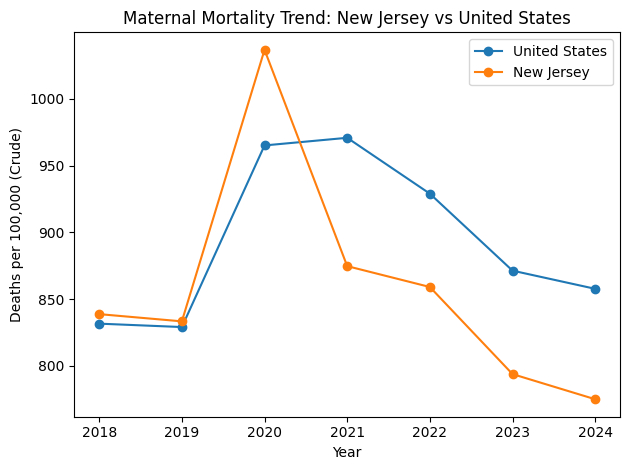

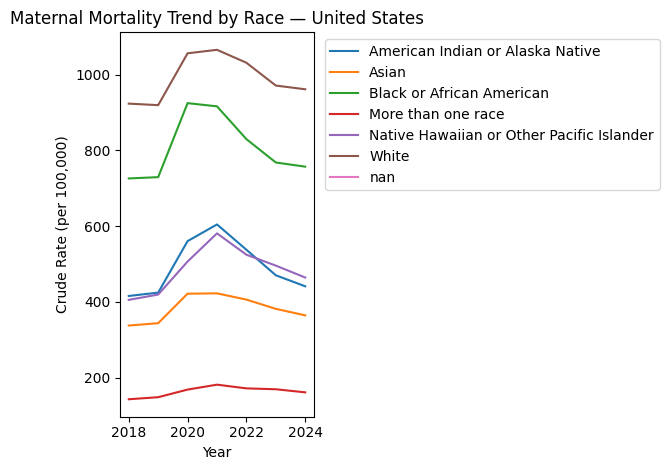

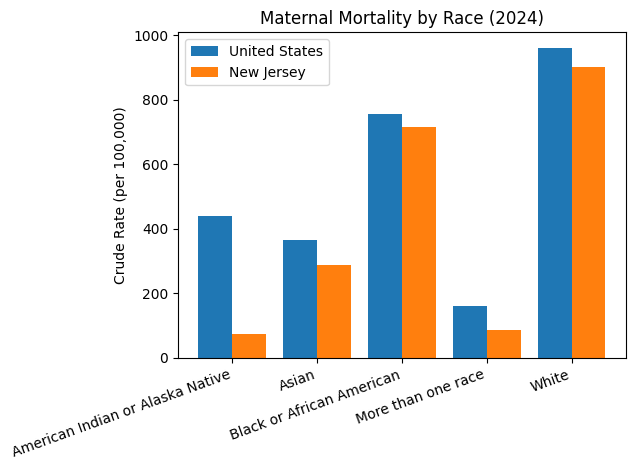

Charts saved to: /Users/kellykroeper


In [17]:
import matplotlib.pyplot as plt
from pathlib import Path

# Save charts in current notebook folder
OUT_DIR = Path(".")
OUT_DIR.mkdir(exist_ok=True)

# =========================
# Chart 1: Overall trend — NJ vs US
# =========================
overall = (
    df.groupby(["location", "year"], as_index=False)
      .agg(deaths=("deaths", "sum"), population=("population", "sum"))
)

overall["rate_per_100k"] = (overall["deaths"] / overall["population"]) * 100_000

plt.figure()
for loc in ["United States", "New Jersey"]:
    sub = overall[overall["location"] == loc].sort_values("year")
    plt.plot(sub["year"], sub["rate_per_100k"], marker="o", label=loc)

plt.title("Maternal Mortality Trend: New Jersey vs United States")
plt.xlabel("Year")
plt.ylabel("Deaths per 100,000 (Crude)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "maternal_mortality_trend_nj_vs_us.png", dpi=200)
plt.show()


# =========================
# Chart 2: Trend by race — United States
# =========================
plt.figure()
us = df[df["location"] == "United States"]

for race in us["race"].unique():
    r = us[us["race"] == race].sort_values("year")
    plt.plot(r["year"], r["rate"], label=race)

plt.title("Maternal Mortality Trend by Race — United States")
plt.xlabel("Year")
plt.ylabel("Crude Rate (per 100,000)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / "maternal_mortality_trend_by_race_us.png", dpi=200)
plt.show()


# =========================
# Chart 3: Latest-year snapshot — NJ vs US
# =========================
latest_year = int(df["year"].max())
latest = df[df["year"] == latest_year]

pivot = (
    latest.pivot_table(index="race", columns="location", values="rate")
          .dropna()
)

plt.figure()
x = range(len(pivot.index))

plt.bar([i - 0.2 for i in x], pivot["United States"], width=0.4, label="United States")
plt.bar([i + 0.2 for i in x], pivot["New Jersey"], width=0.4, label="New Jersey")

plt.xticks(x, pivot.index, rotation=20, ha="right")
plt.title(f"Maternal Mortality by Race ({latest_year})")
plt.ylabel("Crude Rate (per 100,000)")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUT_DIR / f"maternal_mortality_snapshot_by_race_{latest_year}.png",
    dpi=200
)
plt.show()

print("Charts saved to:", OUT_DIR.resolve())

## SQL Layer (SQLite)
Below: Loaded the cleaned CDC WONDER export into SQLite and produced:
- NJ vs US trend rates recomputed from deaths/population
- Race-stratified trend output for reporting
- Latest-year NJ vs US disparity snapshot by race
- Basic data quality checks for missing/suppressed values

In [18]:
import sqlite3
from pathlib import Path


DB_PATH = Path("maternal_health.db")

conn = sqlite3.connect(DB_PATH)

# Write the dataframe into SQLite
df.to_sql("maternal_mortality", conn, if_exists="replace", index=False)

# Helpful indexes
cur = conn.cursor()
cur.execute("CREATE INDEX IF NOT EXISTS idx_mm_year ON maternal_mortality(year);")
cur.execute("CREATE INDEX IF NOT EXISTS idx_mm_loc ON maternal_mortality(location);")
cur.execute("CREATE INDEX IF NOT EXISTS idx_mm_race ON maternal_mortality(race);")
conn.commit()

print("SQLite DB created at:", DB_PATH.resolve())

SQLite DB created at: /Users/kellykroeper/maternal_health.db


In [19]:
import pandas as pd

def q(sql: str) -> pd.DataFrame:
    return pd.read_sql_query(sql, conn)

## Maternal Mortality by location, year, rate per 100k

In [20]:
sql_trend = """
SELECT
  location,
  year,
  SUM(deaths) AS deaths,
  SUM(population) AS population,
  ROUND( (CAST(SUM(deaths) AS REAL) / NULLIF(SUM(population), 0)) * 100000.0, 3 ) AS rate_per_100k
FROM maternal_mortality
GROUP BY location, year
ORDER BY location, year;
"""
trend = q(sql_trend)
trend

,location,year,deaths,population,rate_per_100k
0,New Jersey,2018,38214.0,4556326.0,838.702
1,New Jersey,2019,37802.0,4536440.0,833.297
2,New Jersey,2020,47058.0,4539322.0,1036.675
3,New Jersey,2021,41103.0,4699347.0,874.653
4,New Jersey,2022,40293.0,4690547.0,859.026
5,New Jersey,2023,37455.0,4718529.0,793.786
6,New Jersey,2024,37318.0,4815508.0,774.955
7,United States,2018,2761472.0,332077510.0,831.575
8,United States,2019,2762030.0,333164398.0,829.029
9,United States,2020,3227690.0,334455842.0,965.057


## Maternal Mortality by race 

In [21]:
sql_race_trend = """
SELECT
  location,
  race,
  year,
  deaths,
  population,
  rate AS crude_rate
FROM maternal_mortality
ORDER BY location, race, year;
"""
race_trend = q(sql_race_trend)
race_trend.head(20)

,location,race,year,deaths,population,crude_rate
0,New Jersey,American Indian or Alaska Native,2018,30.0,26569.0,112.9
1,New Jersey,American Indian or Alaska Native,2019,25.0,26864.0,93.1
2,New Jersey,American Indian or Alaska Native,2020,40.0,29240.0,136.8
3,New Jersey,American Indian or Alaska Native,2021,26.0,31297.0,83.1
4,New Jersey,American Indian or Alaska Native,2022,35.0,32664.0,107.2
5,New Jersey,American Indian or Alaska Native,2023,33.0,35262.0,93.6
6,New Jersey,American Indian or Alaska Native,2024,32.0,42642.0,75.0
7,New Jersey,Asian,2018,1105.0,456512.0,242.1
8,New Jersey,Asian,2019,1203.0,455066.0,264.4
9,New Jersey,Asian,2020,1780.0,465077.0,382.7


## Maternal Mortality Rates by Race per year 

In [22]:
sql_latest_snapshot = """
WITH maxyr AS (
  SELECT MAX(year) AS latest_year FROM maternal_mortality
)
SELECT
  m.year,
  m.race,
  ROUND(AVG(CASE WHEN m.location = 'United States' THEN m.rate END), 3) AS us_rate,
  ROUND(AVG(CASE WHEN m.location = 'New Jersey' THEN m.rate END), 3) AS nj_rate,
  ROUND(
    (AVG(CASE WHEN m.location = 'New Jersey' THEN m.rate END) -
     AVG(CASE WHEN m.location = 'United States' THEN m.rate END)), 3
  ) AS nj_minus_us
FROM maternal_mortality m
JOIN maxyr ON m.year = maxyr.latest_year
GROUP BY m.year, m.race
HAVING us_rate IS NOT NULL AND nj_rate IS NOT NULL
ORDER BY nj_minus_us DESC;
"""
latest_snapshot = q(sql_latest_snapshot)
latest_snapshot

,year,race,us_rate,nj_rate,nj_minus_us
0,2024,Black or African American,756.8,716.8,-40.0
1,2024,White,961.1,901.4,-59.7
2,2024,Asian,364.2,289.3,-74.9
3,2024,More than one race,160.9,85.5,-75.4
4,2024,American Indian or Alaska Native,440.9,75.0,-365.9


Missing Data Run 

In [23]:
sql_dq = """
SELECT
  SUM(CASE WHEN year IS NULL THEN 1 ELSE 0 END) AS missing_year,
  SUM(CASE WHEN race IS NULL OR TRIM(race) = '' THEN 1 ELSE 0 END) AS missing_race,
  SUM(CASE WHEN location IS NULL OR TRIM(location) = '' THEN 1 ELSE 0 END) AS missing_location,
  SUM(CASE WHEN deaths IS NULL THEN 1 ELSE 0 END) AS missing_deaths,
  SUM(CASE WHEN population IS NULL THEN 1 ELSE 0 END) AS missing_population,
  SUM(CASE WHEN rate IS NULL THEN 1 ELSE 0 END) AS missing_rate
FROM maternal_mortality;
"""
q(sql_dq)

,missing_year,missing_race,missing_location,missing_deaths,missing_population,missing_rate
0,0,7,0,0,0,0


In [24]:
from pathlib import Path

sql_file = Path("queries.sql")

with open(sql_file, "w") as f:
    f.write("-- Project 2: Maternal Mortality (NJ vs US) - SQL Queries\n\n")
    f.write("-- 1) Overall trend (recomputed from deaths/population)\n")
    f.write(sql_trend.strip() + "\n\n")
    f.write("-- 2) Trend by race (raw rows)\n")
    f.write(sql_race_trend.strip() + "\n\n")
    f.write("-- 3) Latest year snapshot by race (NJ vs US + difference)\n")
    f.write(sql_latest_snapshot.strip() + "\n\n")
    f.write("-- 4) Data quality checks\n")
    f.write(sql_dq.strip() + "\n")

print("Wrote:", sql_file.resolve())

Wrote: /Users/kellykroeper/queries.sql


In [32]:
conn.close()
print("DB connection closed.")

DB connection closed.


## Key Findings (2024)
In 2024, maternal mortality rates differed between New Jersey and the United States, with year-to-year variation underscoring the importance of trend analysis rather than single-year interpretation.
Race-stratified views showed persistent disparities in maternal mortality, with some racial groups experiencing consistently higher crude rates across both state and national levels.
When comparing New Jersey to the U.S. overall, the direction and magnitude of differences varied by race, highlighting how aggregate state-level comparisons can mask subgroup-level patterns.
Recomputing rates directly from deaths and population counts in SQL produced results consistent with reported crude rates, reinforcing data quality and metric traceability.
Because maternal mortality events are relatively rare, crude rates can be unstable for smaller populations, particularly when stratified by race; findings should be interpreted cautiously and in context.

## Analyst Takeaway
This analysis demonstrates how combining Python-based visualization with SQL-based validation supports transparent, reproducible maternal health surveillance and helps surface equity-relevant patterns that may be missed in overall averages.